In [5]:
import pandas as pd  
import matplotlib.pyplot as plt  
import seaborn as sns  
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score



In [6]:

df = pd.read_csv('customer_booking.csv', encoding='latin1') 
df.head()  

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  str    
 2   trip_type              50000 non-null  str    
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  str    
 7   route                  50000 non-null  str    
 8   booking_origin         50000 non-null  str    
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), str(5)
memory usage: 7.0 MB


In [8]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,1.000000,1.000000,1.000000,9.500000,1.000000


In [ ]:
# Count the number of missing values in each feature
df.isnull().sum()  

num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

In [11]:

print(df.dtypes)

num_passengers             int64
sales_channel                str
trip_type                    str
purchase_lead              int64
length_of_stay             int64
flight_hour                int64
flight_day                   str
route                        str
booking_origin               str
wants_extra_baggage        int64
wants_preferred_seat       int64
wants_in_flight_meals      int64
flight_duration          float64
booking_complete           int64
dtype: object


In [ ]:
# Apply One-Hot Encoding to categorical features for machine learning compatibility
df_encoded = pd.get_dummies(df, columns=['sales_channel', 'trip_type', 'flight_day', 'booking_origin', 'route'])

In [14]:
df_encoded.dtypes

num_passengers         int64
purchase_lead          int64
length_of_stay         int64
flight_hour            int64
wants_extra_baggage    int64
                       ...  
route_TRZWUH            bool
route_TRZXIY            bool
route_TWUWUH            bool
route_TWUXIY            bool
route_URTXIY            bool
Length: 924, dtype: object

In [ ]:
# 1. Split the dataset into features (X) and target variable (y)
X = df_encoded.drop('booking_complete', axis=1)
y = df_encoded['booking_complete']

# 2. Divide data into training (80%) and testing (20%) sets to prevent overfitting
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Initialize and train a RandomForestClassifier with 100 decision trees
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 4. Predict on the test set and evaluate the baseline model accuracy
y_pred = model.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2f}")

모델 정확도: 0.85


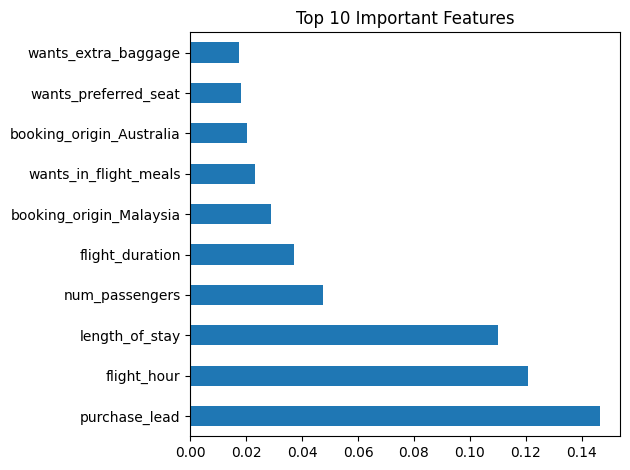

In [ ]:
# Extract feature importance scores from the trained RandomForest model and map them to column names
feature_importances = pd.Series(model.feature_importances_, index=X.columns)

# Visualise the top 10 most influential features driving customer booking predictions using a horizontal bar chart
feature_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.tight_layout() 
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5)
# Calculate and print the mean cross-validation accuracy across all 5 folds
print(f"5-Fold CV Mean Accuracy: {scores.mean():.2f}")

In [ ]:
# Extract the top 3 most influential features and print their exact importance scores
feature_importances = pd.Series(model.feature_importances_, index=X.columns)
print(feature_importances.nlargest(3))

purchase_lead     0.146411
flight_hour       0.120765
length_of_stay    0.110186
dtype: float64
